# Zadanie 1. Kalkulator trajektorii lotu pocisku

Zaimportuj z moduł `math` następujące funkcje:
* `sin` (nazwij `sinus`) - zwraca wartość funkcji sinus dla kąta podanego w radianach;
* `cos` (nazwij `cosinus`) - zwraca wartość funkcji cosinus dla kąta podanego w radianach;
* `radians` (nazwij `deg_to_rad`) - konwertuje wartość ze stopni na radiany;
* `pow` (nazwij `potega`) - oblicza potęgę ustalonego stopnia.

Program pyta użytkownika o dwie wartości:
* $v$ - prędkość wylotowa pocisku (m/s);
* $\theta$ - kąt wyrzutu pocisku (stopnie).

Następnie program oblicza:
* maksymalną wysokość jaką osiągnie pocisk w trakcie lotu: $h_{max}=\frac{v^2\cdot sin^2(\theta_r)}{2g}$
* czas lotu pocisku: $t=\frac{2v\cdot sin(\theta_r)}{g}$
* zasięg pocisku: $\text{range}=\frac{v^2\cdot sin(2\theta_r)}{g}$

gdzie:
* $g$ - przyspieszenie ziemskie: $g=9.81\space m/s^2$
* $\theta_r$ - kąt wyrzutu pocisku wyrażony w radianach: $\theta_r=\text{deg\_to\_rad} (\theta)$

Program wypisuje wynik na ekran z dokładnością do dwóch miejsc po przecinku i ze stosownym opisem.

In [ ]:
from math import sin as sinus
from math import cos as cosinus
from math import radians as deg_to_rad
from math import pow as potega

In [ ]:
v = float(input("podaj prędkość wylotową pocisku (m/s): "))
theta = float(input("podaj kąt wyrzutu pocisku (w stopniach): "))
g = 9.81

max = (potega(v, 2) * potega(sinus(deg_to_rad(theta)), 2)) / 2 * g
t = (2 * v * sinus(deg_to_rad(theta))) / g
range = (potega(v, 2) * sinus(2*deg_to_rad(theta))) / g

#TEST

print(max)
print(t)
print(range)

# Zadanie 2. Analiza sekwencji genetycznych.

Zaimportuj z modułu `random` następujące funkcje:
* `choice` - losuje jedną wartość z podanego zestawu opcji;
* `random` - losuje wartość z przedziału $0-1$.

Zaimplementuj następujące funkcje:
* `generuj_dna(d: int) -> str`: funkcja przyjmuje jako parametr długość sekwencji do wygenerowania i zwraca sekwencję DNA wygenerowaną w sposób losowy opierając się na słowniku znanych nukleotydów;
* `mutuj_dna(sekwencja: str, pr_mut: float) -> str`: funkcja przyjmuje dwa parametry: sekwencja DNA i prawdopodobieństwo mutacji, dokonuje losowych zmian w oryginalnej sekwencji i zwraca sekwencję zmutowaną;
* `podobienstwo(sekwencja1, sekwencja2) -> float`: funkcja jako parametry przyjmuje dwie sekwencje i następnie oblicza liczbę różnic między sekwencjami. Następnie oblicza procentową zawartość różnic w stosunku do długości pierwszej sekwencji i zwraca podobieństwo wyrażone jako $\text{podobieństwo}=1-\frac{\text{liczba różnic}}{\text{długść sekwencji}}$.

Program generuje sekwencję ustalonej długości. Następnie dokonuje mutacji tej sekwencji i oblicza podobieństwo sekwencji oryginalnej do zmutowanej. Na koniec wypisuje na ekran podobieństwo obu sekwencji wyrażone jako wartość procentowa w zaokrągleniu do 2 miejsc po przecinku. Dodatkowo, jeżeli podobieństwo obu sekwencji jest większe niż $97\%$ to program wypisuje na ekran komunikat, że obie sekwencje pochodzą od organizmów tego samego gatunku.

In [2]:
from random import choice
from random import random as los

In [4]:
#1
def gen_dna(d: int):
    nukl = ['A', 'C', 'G', 'T']
    seq = ""

    for _ in range(d):
        seq += choice(nukl)
    return seq
#2
def mutuj_dna(seq, pr_mut):
    zmutowana = ""
    nukl = ['A', 'C', 'G', 'T']

    for nukld in seq:
        if los() <= pr_mut:
            zmutowana += choice(nukl)
        else:
            zmutowana += nukld
    return zmutowana
#3
def pr_stwo(seq1, seq2):
    roznice = 0

    for i in range(len(seq1)):
        if seq1[i] != seq2[i]:
            roznice += 1
    
    wynik = 1 - (roznice / len(seq1))
    return wynik


seq = gen_dna(20)
print(f"orginalna sekwencja: {seq}")

mut = mutuj_dna(seq, 0.3)
print(f"zmutowana sekwencja: {mut}")

p = pr_stwo(seq, mut)
proc = round(p *100, 2)
print(f"prawdopodobieństwo tych dwóch sekwencji to {proc}%!")

if p > 0.97:
    print(f"obie sekwencje pochodzą od tego samego gatunku :)")
else:
    print("te sekwencje nie pochodzą od tego samego gatunku")



orginalna sekwencja: TACAGATTGAATCAGCGTAA
zmutowana sekwencja: TCCAGAGTGATTCAGCGTAA
prawdopodobieństwo tych dwóch sekwencji to 85.0%!
te sekwencje nie pochodzą od tego samego gatunku


# Zadanie 3. Oczyszczanie metadanych środowiskowych.

Zaimportuj moduł pandas i przypisz mu stosowną nazwę. Wczytaj zestaw danych `data/environmental_metadata.csv`. Jest to zbiór metadanych opisujących próbki pobrane ze środowiska na terenie Polski. Posiada on następujący zestaw cech:
* site: nazwa stanowiska
* season: pora roku, w której pobierana była próba
* depth: głębokość wody z jakiej pobrano próbę, standardowo próbkę pobierano na trzech głębokościach: 20 cm, 50 cm i 80 cm
* molecule: nazwa cząsteczki jaka była izolowana z próbki: DNA lub RNA
* rep_number: numer powtórzenia, każda próba była pobierana 5 razy w 5 różnych miejscach na jednym stanowisku
* latitude: szerokość geograficzna stanowiska
* longitude: długość geograficzna stanowiska
* temperature: temperatura powietrza podczas pobierania próbki
* humidity: wilgotność powietrza podczas pobierania próbki
* particles: średnia liczba cząsteczek stałych w jednym militrze pobranej próbki
* comment: komentarz osoby pobierającej próbę o szczególnych okolicznościach podczas pobierania próbki.

Oczyść dane wykonując następujące kroki:
1. Sprawdź czy zestaw zawiera brakujące dane. Jeżeli tak, użyj metody `.dropna()` aby pozbyć się braków. Zwróć uwagę na to czy należy usunąć wiersze czy kolumny.
2. Sprawdź czy wszystkie zmienne mają taki typ jaki powinny mieć (użyj metody `.info()` na całej tabeli). Jeżeli nie, podmień taką zmienną na przekonwertowaną z użyciem metody `.astype()` na konkretnej kolumnie (serii danych).
3. Przeszukaj zbiór pod kątem niepoprawnych wartości analizując wartości zmiennych merytorycznie, np. szerokość geograficzna obejmuje wartości z przedziału od $-90^o$ do $+90^o$. Wykorzystaj do tego analizę podstawowych statystyk (metoda `.describe()`).
4. Usuń zidentyfikowane niepoprawne wiersze ze zbioru.

Sprawdź ile wierszy i ile kolumn zostało usuniętych ze zbioru. Wynikowy zestaw danych zapisz do pliku `data/environmental_metadata_clean.csv`.

In [5]:
import pandas as pd
env = pd.read_csv("data/environmental_metadata.csv")

In [6]:
env.head()

,site,season,depth,molecule,rep_number,latitude,longitude,temperature,humidity,particles,comment
0,stanowisko_1,spring,20.0,DNA,1.0,50.504714,15.996064,15.0,65.0,489.664734,NaN
1,stanowisko_1,spring,20.0,RNA,1.0,50.504714,15.996064,15.0,65.0,520.061491,NaN
2,stanowisko_1,spring,50.0,DNA,1.0,50.504714,15.996064,15.0,65.0,215.970936,NaN
3,stanowisko_1,spring,50.0,RNA,1.0,50.504714,15.996064,15.0,65.0,725.342452,NaN
4,stanowisko_1,spring,80.0,DNA,1.0,50.504714,15.996064,15.0,65.0,823.053115,NaN


In [7]:
env.isna().sum()

site              2
season            4
depth             1
molecule          1
rep_number        0
latitude          1
longitude         2
temperature       0
humidity          2
particles         1
comment        1494
dtype: int64

In [ ]:
env = env.drop(columns="comment") #usunięcie kolumny z komentarzami, tam jest najwięcej braków

In [9]:
env.isna().sum()

site           2
season         4
depth          1
molecule       1
rep_number     0
latitude       1
longitude      2
temperature    0
humidity       2
particles      1
dtype: int64

In [11]:
env.dropna(inplace=True)

In [13]:
env.isna().sum().sum()

np.int64(0)

In [14]:
env.info()

<class 'pandas.DataFrame'>
Index: 1516 entries, 0 to 1528
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   site         1516 non-null   str    
 1   season       1516 non-null   str    
 2   depth        1516 non-null   float64
 3   molecule     1516 non-null   str    
 4   rep_number   1516 non-null   float64
 5   latitude     1516 non-null   float64
 6   longitude    1516 non-null   float64
 7   temperature  1516 non-null   float64
 8   humidity     1516 non-null   float64
 9   particles    1516 non-null   float64
dtypes: float64(7), str(3)
memory usage: 130.3 KB


In [15]:
env["rep_number"] = env["rep_number"].astype(int)

In [16]:
env.info()

<class 'pandas.DataFrame'>
Index: 1516 entries, 0 to 1528
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   site         1516 non-null   str    
 1   season       1516 non-null   str    
 2   depth        1516 non-null   float64
 3   molecule     1516 non-null   str    
 4   rep_number   1516 non-null   int64  
 5   latitude     1516 non-null   float64
 6   longitude    1516 non-null   float64
 7   temperature  1516 non-null   float64
 8   humidity     1516 non-null   float64
 9   particles    1516 non-null   float64
dtypes: float64(6), int64(1), str(3)
memory usage: 130.3 KB


In [17]:
env.describe()

,depth,rep_number,latitude,longitude,temperature,humidity,particles
count,1516.000000,1516.000000,1516.000000,1516.000000,1516.000000,1516.000000,1516.000000
mean,49.920844,3.002639,51.933565,19.503498,17.851583,57.476253,502.950912
std,24.543227,1.415144,16.836067,7.352846,12.830235,25.072491,301.554423
min,20.000000,1.000000,5.003142,1.873976,-73.000000,-7.000000,-456.989559
25%,20.000000,2.000000,50.504714,16.918580,9.000000,40.000000,303.307539
50%,50.000000,3.000000,50.865460,19.694106,18.000000,58.000000,510.032787
75%,80.000000,4.000000,52.314923,21.018274,25.000000,74.250000,700.868571
max,80.000000,5.000000,516.946116,220.776616,311.000000,117.000000,1386.492342


In [19]:
env["particles"].nsmallest(n=50) #ponad 50 wpisów na minusie


82     -456.989559
754    -373.944203
1250   -349.185907
47     -347.342008
1355   -341.655915
569    -313.051393
442    -309.464172
808    -295.509780
1012   -293.875634
294    -280.338347
590    -271.030767
147    -246.715173
287    -246.711799
1165   -239.613163
1514   -233.125685
1254   -215.931999
91     -185.636644
1372   -180.961170
7      -170.303371
406    -164.966480
266    -159.023815
1073   -155.881161
9      -152.409994
835    -152.389105
1025   -148.090065
1313   -136.796216
723    -134.833561
352    -133.656123
139    -131.809868
726    -131.046672
793    -130.554756
1241   -130.366529
993    -125.415602
608    -121.395658
75     -121.200343
597    -112.424571
109    -102.119625
1190    -98.242887
1013    -97.863211
456     -95.417404
480     -84.251863
968     -82.787587
606     -82.255208
1469    -79.977425
897     -78.900293
1343    -77.505961
989     -72.899824
170     -72.444373
357     -72.310779
952     -69.381331
Name: particles, dtype: float64

In [20]:
env = env[env["particles"] >= 0] #usuniecie minusowych wartosci particles

In [21]:
env["particles"].nsmallest()

662      0.373958
601      1.724223
1465     1.865549
23       3.289002
787     10.946273
Name: particles, dtype: float64

In [22]:
env["temperature"].nsmallest() #358 ma -73 stopnie, troche zimno


358   -73.0
384    -5.0
385    -5.0
386    -5.0
387    -5.0
Name: temperature, dtype: float64

In [25]:
env["humidity"].nsmallest(n=20)

834   -7.0
836   -7.0
837   -7.0
839   -7.0
498   -6.0
499   -6.0
500   -6.0
501   -6.0
502   -6.0
503   -6.0
492    6.0
493    6.0
494    6.0
495    6.0
496    6.0
828    7.0
829    7.0
830    7.0
831    7.0
832    7.0
Name: humidity, dtype: float64

In [26]:
env = env[env["humidity"] >= 0] #usuniecie minusowych wartosci

In [28]:
env["longitude"].nsmallest() #125

125      1.873976
1260    15.356903
1261    15.356903
1262    15.356903
1263    15.356903
Name: longitude, dtype: float64

In [29]:
env["latitude"].nsmallest() #932

932     5.003142
901    50.031419
902    50.031419
903    50.031419
904    50.031419
Name: latitude, dtype: float64

In [31]:
env["temperature"].nlargest() #1034 ma 311 stopni

1034    311.0
762      39.0
763      39.0
764      39.0
765      39.0
Name: temperature, dtype: float64

In [32]:
env["humidity"].nlargest() 

444    117.0
445    117.0
446    117.0
447    117.0
448    117.0
Name: humidity, dtype: float64

In [33]:
env["longitude"].nlargest() #884, 1354

894     220.776616
1354    196.334225
720      22.822394
721      22.822394
722      22.822394
Name: longitude, dtype: float64

In [34]:
env["latitude"].nlargest() #1121, 324

1121    516.946116
324     506.118259
450      53.666977
451      53.666977
452      53.666977
Name: latitude, dtype: float64

In [36]:
remv = [125, 932, 1034, 884, 1354, 1121, 324, 358]

In [37]:
env.drop(remv, inplace=True)

In [38]:
env.info()

<class 'pandas.DataFrame'>
Index: 1420 entries, 0 to 1528
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   site         1420 non-null   str    
 1   season       1420 non-null   str    
 2   depth        1420 non-null   float64
 3   molecule     1420 non-null   str    
 4   rep_number   1420 non-null   int64  
 5   latitude     1420 non-null   float64
 6   longitude    1420 non-null   float64
 7   temperature  1420 non-null   float64
 8   humidity     1420 non-null   float64
 9   particles    1420 non-null   float64
dtypes: float64(6), int64(1), str(3)
memory usage: 122.0 KB


In [39]:
env = env.reset_index(drop=True)

In [40]:
env.info() #1420 wierszy, 10 kolumn

<class 'pandas.DataFrame'>
RangeIndex: 1420 entries, 0 to 1419
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   site         1420 non-null   str    
 1   season       1420 non-null   str    
 2   depth        1420 non-null   float64
 3   molecule     1420 non-null   str    
 4   rep_number   1420 non-null   int64  
 5   latitude     1420 non-null   float64
 6   longitude    1420 non-null   float64
 7   temperature  1420 non-null   float64
 8   humidity     1420 non-null   float64
 9   particles    1420 non-null   float64
dtypes: float64(6), int64(1), str(3)
memory usage: 111.1 KB


In [41]:
og = pd.read_csv("data/environmental_metadata.csv")

In [42]:
og.info() #1530 wierszy, 11 kolumn

<class 'pandas.DataFrame'>
RangeIndex: 1530 entries, 0 to 1529
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   site         1528 non-null   str    
 1   season       1526 non-null   str    
 2   depth        1529 non-null   float64
 3   molecule     1529 non-null   str    
 4   rep_number   1530 non-null   float64
 5   latitude     1529 non-null   float64
 6   longitude    1528 non-null   float64
 7   temperature  1530 non-null   float64
 8   humidity     1528 non-null   float64
 9   particles    1529 non-null   float64
 10  comment      36 non-null     str    
dtypes: float64(7), str(4)
memory usage: 131.6 KB


In [43]:
wow = 1530 - 1420
print(f"zostalo usuniete {wow} wieszy oraz jedna kolumna (komentarze)")

zostalo usuniete 110 wieszy oraz jedna kolumna (komentarze)


In [44]:
env.to_csv("data/environmental_metadata_clean.csv")

# Zadanie 4. Grupowanie i agregacja danych.

Wczytaj oczyszczony zestaw danych `data/environmental_metadata_clean.csv`. 
1. Zbadaj ile powtórzeń każdej próby pozostało w zbiorze dla każdego stanowiska, w każdym sezonie, z każdej głębokości i dla każdej molekuły. 
2. Oblicz średnią temperaturę i wilgotność jaka panowała w momencie poboru prób na każdym stanowisku w każdej porze roku.
3. Sprawdź ile średnio cząsteczek występowało w próbce na jesień, na głębokości 50 cm na stanowisku trzecim i czwartym.

In [48]:
clean_env = pd.read_csv("data/environmental_metadata_clean.csv")

In [49]:
clean_env.head()

,Unnamed: 0,site,season,depth,molecule,rep_number,latitude,longitude,temperature,humidity,particles
0,0,stanowisko_1,spring,20.0,DNA,1,50.504714,15.996064,15.0,65.0,489.664734
1,1,stanowisko_1,spring,20.0,RNA,1,50.504714,15.996064,15.0,65.0,520.061491
2,2,stanowisko_1,spring,50.0,DNA,1,50.504714,15.996064,15.0,65.0,215.970936
3,3,stanowisko_1,spring,50.0,RNA,1,50.504714,15.996064,15.0,65.0,725.342452
4,4,stanowisko_1,spring,80.0,DNA,1,50.504714,15.996064,15.0,65.0,823.053115


In [51]:
#1
rep = clean_env.groupby(["site", "season", "depth", "molecule"])["rep_number"].count()
print(f'''ilość powtorzeń: 
{rep}''')

ilość powtorzeń: 
site          season  depth  molecule
stanowisko_1  autumn  20.0   DNA         5
                             RNA         5
                      50.0   DNA         5
                             RNA         4
                      80.0   DNA         4
                                        ..
stanowisko_9  summer  20.0   RNA         5
                      50.0   DNA         5
                             RNA         5
                      80.0   DNA         4
                             RNA         5
Name: rep_number, Length: 306, dtype: int64


In [53]:
#2
clean_env.groupby(["season", "site"])[["temperature", "humidity"]].mean().abs()

temperature    humidity
season site                                  
autumn stanowisko_1     17.178571   73.964286
       stanowisko_10    14.714286   44.250000
       stanowisko_11    14.666667   57.851852
       stanowisko_12    27.071429   41.285714
       stanowisko_13     8.571429   55.535714
       stanowisko_14     7.192308   42.153846
       stanowisko_15    16.785714   19.464286
       stanowisko_16     6.892857   71.214286
       stanowisko_17     6.000000   67.384615
       stanowisko_2     17.034483   42.620690
       stanowisko_3     15.482759   58.586207
       stanowisko_4      0.407407   94.555556
       stanowisko_5     18.862069  103.620690
       stanowisko_6      3.000000   73.000000
       stanowisko_7     11.928571   79.785714
       stanowisko_8      3.800000   54.200000
       stanowisko_9      9.076923   27.346154
spring stanowisko_1     16.407407   70.037037
       stanowisko_10    12.173913   11.086957
       stanowisko_11    10.214286   76.678571
       stanowisko_12     6.680000   79.320000
       stanowisko_13    21.827586   62.103448
       stanowisko_14    18.379310   62.172414
       stanowisko_15    23.642857   78.035714
       stanowisko_16    11.333333   62.333333
       stanowisko_17     5.862069   69.862069
       stanowisko_2     17.666667   94.148148
       stanowisko_3     22.629630   42.814815
       stanowisko_4      1.678571   89.107143
       stanowisko_5      1.600000   24.400000
       stanowisko_6      8.892857   89.928571
       stanowisko_7     21.517241   38.275862
       stanowisko_8     11.000000   35.200000
       stanowisko_9     22.538462   47.192308
summer stanowisko_1     26.068966   30.862069
       stanowisko_10    27.000000   54.000000
       stanowisko_11    20.555556   56.444444
       stanowisko_12    34.857143   59.464286
       stanowisko_13    22.678571   44.321429
       stanowisko_14    20.600000   66.400000
       stanowisko_15    25.392857   19.714286
       stanowisko_16    28.310345   56.448276
       stanowisko_17    16.200000   49.600000
       stanowisko_2     32.185185   22.481481
       stanowisko_3     32.000000   90.607143
       stanowisko_4     33.137931   75.689655
       stanowisko_5     29.230769   80.807692
       stanowisko_6     34.142857   10.142857
       stanowisko_7     25.615385   59.461538
       stanowisko_8     29.400000   99.800000
       stanowisko_9     36.965517   24.482759

In [54]:
#3
sos = (clean_env["season"] == "autumn") & (clean_env["depth"] == 50.0) & (clean_env["site"].isin(["stanowisko_3", "stanowisko_4"]))

avg_prt = env[sos]["particles"].mean().round(2)
print(f"średnia liczba cząsteczek (jesień, 50cm, stanowiska 3 i 4): {avg_prt}")

średnia liczba cząsteczek (jesień, 50cm, stanowiska 3 i 4): 442.84


# Zadanie 5. Filtrowanie danych

Wczytaj zestaw danych `data/environmental_metadata_clean.csv`.

1. Wybierz z zestawu tylko próbki pobrane na stanowiskach na północ od Łodzi.
2. Wybierz z zestawu tylko próbki pobrane wiosną i jesienią.

In [ ]:
#1
boat = 51.75
nboat = clean_env[clean_env["latitude"] > boat] #na polnoc to wyzsza szerokosc geo

print(f"liczba próbek na północ od Łodzi: {len(nboat)}")

nboat.head()

liczba próbek na północ od Łodzi: 419


,Unnamed: 0,site,season,depth,molecule,rep_number,latitude,longitude,temperature,humidity,particles
420,420,stanowisko_6,spring,20.0,DNA,1,53.666977,20.910211,8.0,93.0,781.353108
421,421,stanowisko_6,spring,20.0,RNA,1,53.666977,20.910211,8.0,93.0,503.170100
422,422,stanowisko_6,spring,50.0,DNA,1,53.666977,20.910211,8.0,93.0,879.424005
423,423,stanowisko_6,spring,50.0,RNA,1,53.666977,20.910211,8.0,93.0,561.992839
424,424,stanowisko_6,spring,80.0,DNA,1,53.666977,20.910211,8.0,93.0,1135.388245


In [56]:
#2
spritun = (clean_env["season"]).isin(["autumn", "spring"])

clean_env[spritun]

,Unnamed: 0,site,season,depth,molecule,rep_number,latitude,longitude,temperature,humidity,particles
0,0,stanowisko_1,spring,20.0,DNA,1,50.504714,15.996064,15.0,65.0,489.664734
1,1,stanowisko_1,spring,20.0,RNA,1,50.504714,15.996064,15.0,65.0,520.061491
2,2,stanowisko_1,spring,50.0,DNA,1,50.504714,15.996064,15.0,65.0,215.970936
3,3,stanowisko_1,spring,50.0,RNA,1,50.504714,15.996064,15.0,65.0,725.342452
4,4,stanowisko_1,spring,80.0,DNA,1,50.504714,15.996064,15.0,65.0,823.053115
...,...,...,...,...,...,...,...,...,...,...,...
1415,1415,stanowisko_17,autumn,80.0,RNA,4,51.326181,19.694106,5.0,70.0,318.787099
1416,1416,stanowisko_17,autumn,20.0,DNA,5,51.326181,19.694106,3.0,58.0,339.862406
1417,1417,stanowisko_17,autumn,20.0,RNA,5,51.326181,19.694106,3.0,58.0,396.270516
1418,1418,stanowisko_17,autumn,50.0,DNA,5,51.326181,19.694106,3.0,58.0,638.473940


# Zadanie 6. Analiza porównawcza

Odnieś się do podzbiorów danych uzyskanych w poprzednim zadaniu i wykonaj poniższe polecenia:
1. Z podzbioru stanowisk z północnej Polski wyodrębnionych w poprzednim zadaniu oblicz średnią temperaturę o każdej zbadanej porze roku. Oblicz to samo dla pozostałych stanowisk. Odpowiedz czy średnia temperatura na północy Polski jest widocznie wyższa niż na południu.
2. Z podzbioru prób zebranych wiosną i jesienią wyodrębnionych w poprzednim zadaniu oblicz średnią temperaturę i średnią wilgotność dla każdego stanowiska. Wykonaj zestawienie tych wartości z danymi dla całego roku. Oblicz różnicę tych wartości i odpowiedz czy istnieje wyraźny trend dla temperatury i wilgotności w chłodniejszych porach roku w stosunku do całego roku.
3. Sprawdź czy istnieje różnica w liczbie cząsteczek w wodzie w próbach pobranych wiosną i jesienią w stosunku do prób pobranych latem. Zbadaj trend dla poszczególnych głębokości.

In [ ]:
#1
nb_temp = nboat.groupby(["season"])["temperature"].mean()
print(f'''średnie temperatury na północy polski: 
{nb_temp}''')

sboat = clean_env[clean_env["latitude"] < boat]
sb_temp = sboat.groupby(["season"])["temperature"].mean()
print(f'''średnie temperatury na południu polski: 
{sb_temp}''')

#średnia temperatura na północy polski jest widocznie niższa niż na południu w okresie jesieni,
#średnia temperatura w okresie wiosny i lata jest porównywalna na północy i południu

średnie temperatury na północy polski: 
season
autumn     7.014085
spring    12.394161
summer    27.485714
Name: temperature, dtype: float64
średnie temperatury na południu polski: 
season
autumn    13.729730
spring    13.987988
summer    27.889552
Name: temperature, dtype: float64


In [61]:
#2
mean_spr_aut = clean_env[spritun].groupby("site")[["temperature", "humidity"]].mean()
mean_year = clean_env.groupby("site")[["temperature", "humidity"]].mean()

trend = (mean_spr_aut - mean_year).abs()

print(f'''różnica parametrów:
{trend}''')

#nie można określić dokładnego trendu, 
#na niektórych stanowiskach pomiary były wykonywane tylko na wiosne/ jesien

różnica parametrów:
               temperature   humidity
site                                 
stanowisko_1      3.200000  14.214935
stanowisko_10     4.974582   9.150327
stanowisko_11     2.685366   3.619290
stanowisko_12     6.016306   0.082227
stanowisko_13     2.425387   4.794840
stanowisko_14     2.650267   4.832086
stanowisko_15     1.726190   9.678571
stanowisko_16     6.641558   3.592641
stanowisko_17     3.625668   6.737968
stanowisko_2      4.829389  14.632960
stanowisko_3      4.357143  13.208333
stanowisko_4     11.076407   5.555628
stanowisko_5      6.354138   5.343370
stanowisko_6      7.522261  18.881275
stanowisko_7      2.759248   0.248996
stanowisko_8      7.333333  18.366667
stanowisko_9      7.575024   4.577873


<Axes: xlabel='site'>

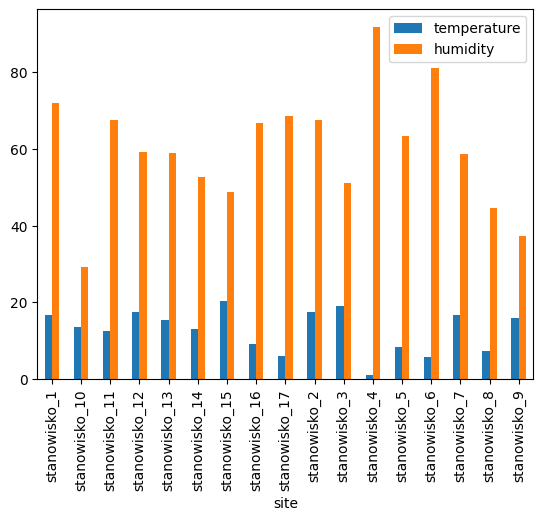

In [63]:
mean_spr_aut.plot(kind="bar")

<Axes: xlabel='site'>

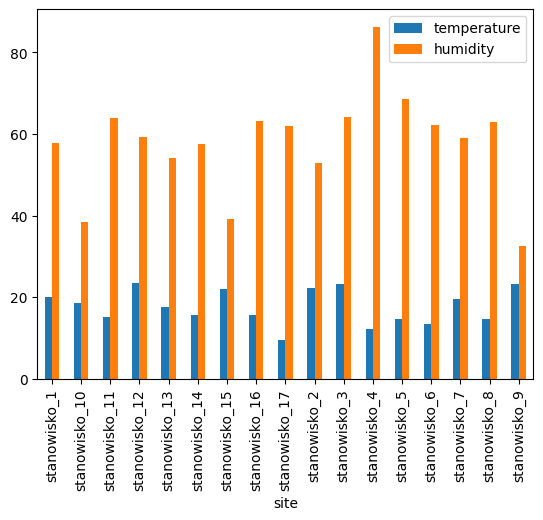

In [64]:
mean_year.plot(kind="bar")

In [66]:
mol_spr_aut = clean_env[spritun].groupby("depth")["particles"].mean()
mol_sum = clean_env[clean_env["season"] == "summer"].groupby("depth")["particles"].mean()

mol_trend = mol_spr_aut - mol_sum
mol_trend = mol_trend.abs()
print(f'''trend cząsteczek wg głębokości:
{mol_trend}
cząsteczki wg głębokości (lato)
{mol_sum}
cząsteczki wg głębokości (jesień i wiosna)
{mol_spr_aut}''')

trend cząsteczek wg głębokości:
depth
20.0    37.021306
50.0    24.594200
80.0    21.387977
Name: particles, dtype: float64
cząsteczki wg głębokości (lato)
depth
20.0    563.408917
50.0    519.967710
80.0    522.917452
Name: particles, dtype: float64
cząsteczki wg głębokości (jesień i wiosna)
depth
20.0    526.387611
50.0    544.561910
80.0    544.305429
Name: particles, dtype: float64
